In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
df = pd.read_csv("data/train.csv")

In [33]:
df.head()       # ilk 5 satır

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [34]:
df.shape        # kaç satır, kaç kolon

(891, 12)

In [35]:
df.columns      # kolon isimleri

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [36]:
df.info()       # veri tipleri + eksik değer özeti

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [37]:
df.describe()   # sayısal kolonların istatistikleri

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [38]:
df.isnull().sum()   # her kolonda kaç tane boş değer var

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [39]:
df["Sex"]       # Age kolonunu getir

0        male
1      female
2      female
3      female
4        male
        ...  
886      male
887    female
888    female
889      male
890      male
Name: Sex, Length: 891, dtype: object

In [40]:
df["Sex"].value_counts()   # kaç kişi hayatta, kaç kişi değil


Sex
male      577
female    314
Name: count, dtype: int64

## Veri Hakkında Genel Bulgular

- 891 yolcu, 12 değişken mevcut
- Age kolonunda 177, Cabin kolonunda 687 eksik değer var
- Yolcuların yalnızca %38'i hayatta kaldı
- Bilet fiyatları arasında ciddi bir uçurum var (0 - 512 pound)

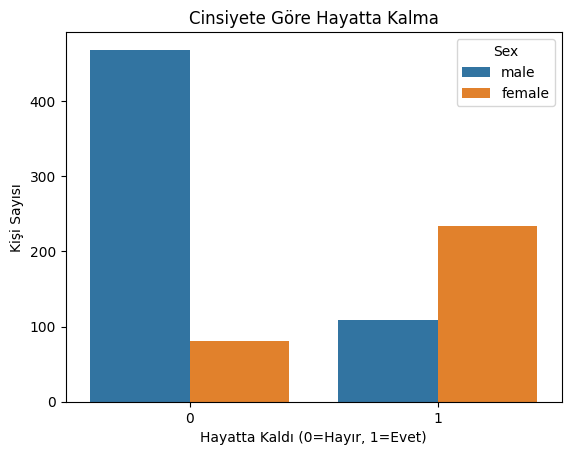

In [41]:
sns.countplot(data=df, x="Survived", hue="Sex")
plt.title("Cinsiyete Göre Hayatta Kalma")
plt.xlabel("Hayatta Kaldı (0=Hayır, 1=Evet)")
plt.ylabel("Kişi Sayısı")
plt.show()

## Bulgu 1: Cinsiyet ve Hayatta Kalma
Hayatta kalanların büyük çoğunluğu kadın, hayatta kalmayanların büyük çoğunluğu erkek.
Bu, gemide "önce kadınlar ve çocuklar" kuralının uygulandığını gösteriyor.

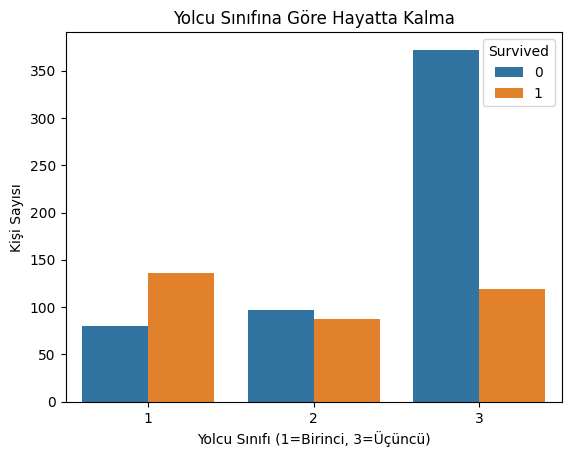

In [42]:
sns.countplot(data=df, x="Pclass", hue="Survived")
plt.title("Yolcu Sınıfına Göre Hayatta Kalma")
plt.xlabel("Yolcu Sınıfı (1=Birinci, 3=Üçüncü)")
plt.ylabel("Kişi Sayısı")
plt.show()

## Bulgu 2: Yolcu Sınıfı ve Hayatta Kalma
3. sınıf yolcuların ölüm oranı diğerlerine kıyasla çok daha yüksek.
1.sınıf yolcular en yüksek hayatta kalma oranına sahip.
Bu muhtemelen 1. sınıf yolcuların güverte erişimi ve kurtarma botlarına yakınlığıyla ilişkili.

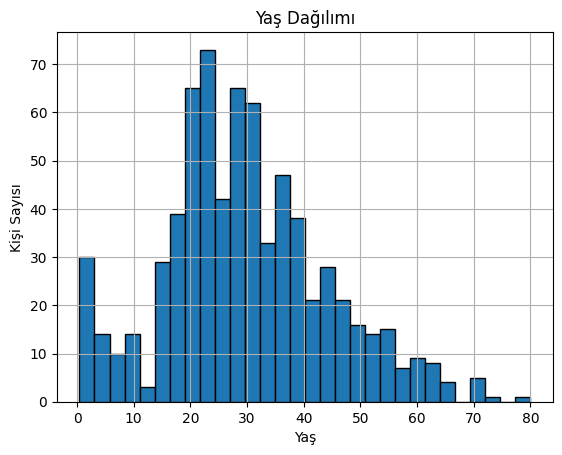

In [43]:
df["Age"].hist(bins=30, edgecolor="black")
plt.title("Yaş Dağılımı")
plt.xlabel("Yaş")
plt.ylabel("Kişi Sayısı")
plt.show()

## Bulgu 3: Yaş Dağılımı
Yolcular yeni doğan bebeklerden 80 yaşına kadar geniş bir aralıkta.
En yoğun grup 15-45 yaş arası, tepe nokta 22-24 civarında.
Genç yetişkinler gemideki en kalabalık grubu oluşturuyor.

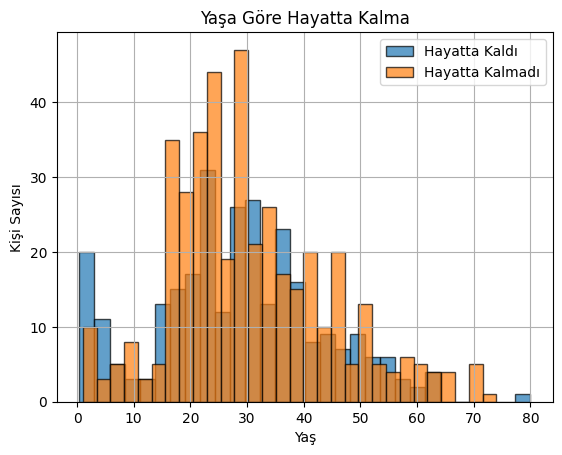

In [44]:
df[df["Survived"] == 1]["Age"].hist(bins=30, alpha=0.7, label="Hayatta Kaldı", edgecolor="black")
df[df["Survived"] == 0]["Age"].hist(bins=30, alpha=0.7, label="Hayatta Kalmadı", edgecolor="black")
plt.title("Yaşa Göre Hayatta Kalma")
plt.xlabel("Yaş")
plt.ylabel("Kişi Sayısı")
plt.legend()
plt.show()

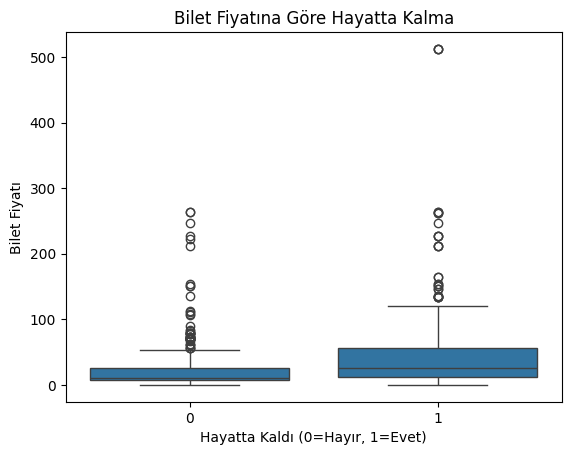

In [45]:
sns.boxplot(data=df, x="Survived", y="Fare")
plt.title("Bilet Fiyatına Göre Hayatta Kalma")
plt.xlabel("Hayatta Kaldı (0=Hayır, 1=Evet)")
plt.ylabel("Bilet Fiyatı")
plt.show()

## Bulgu 4: Bilet Fiyatı ve Hayatta Kalma
Hayatta kalanların medyan bilet fiyatı daha yüksek.
Pahalı bilet alan yolcular büyük ihtimalle 1. sınıftaydı
ve hayatta kalma oranları daha yüksekti.

In [46]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df["Embarked"].isnull().sum()

np.int64(0)

In [47]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Age"].isnull().sum()

np.int64(0)

In [48]:
df = df.drop(columns=["Cabin"])

In [49]:
df = df.drop(columns=["PassengerId", "Name", "Ticket"])

In [50]:
df.columns      

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')

In [51]:
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
df["Embarked"] = df["Embarked"].map({"S": 0, "C": 1, "Q": 2})

In [52]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0
1,1,1,1,38.0,1,0,71.2833,1
2,1,3,1,26.0,0,0,7.9250,0
3,1,1,1,35.0,1,0,53.1000,0
4,0,3,0,35.0,0,0,8.0500,0


## Veri Ön İşleme Özeti
- Embarked: 2 eksik değer mod ile dolduruldu
- Age: 177 eksik değer medyan ile dolduruldu
- Cabin: %77 eksik olduğu için tamamen atıldı
- PassengerId, Name, Ticket: modele katkısı olmadığı için atıldı
- Sex ve Embarked: sayısal değerlere dönüştürüldü
- Geriye 8 anlamlı kolon kaldı, veri modele hazır

In [54]:
X = df.drop(columns=["Survived"])
y = df["Survived"]

print(X.shape)
print(y.shape)

(891, 7)
(891,)


In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(712, 7)
(179, 7)


In [57]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [58]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Doğruluk oranı:", accuracy_score(y_test, y_pred))

Doğruluk oranı: 0.7988826815642458


## Model Sonucu: Logistic Regression
- Eğitim verisi: 712 yolcu (%80)
- Test verisi: 179 yolcu (%20)
- Doğruluk oranı: %80

Model, hiç görmediği yolcuların hayatta kalıp kalmadığını
%80 doğrulukla tahmin edebildi.

In [59]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[89 16]
 [20 54]]
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



## Model Değerlendirmesi
- 179 test yolcusundan 143'ü doğru tahmin edildi
- 16 yolcu yanlış "yaşadı" tahmin edildi
- 20 yolcu yanlış "öldü" tahmin edildi
- Sınıf dengesizliği nedeniyle model ölenleri daha iyi tahmin ediyor